# Projet ML — German Credit Risk
**Objectif :** Prédire si un client est un *bon* (1) ou *mauvais* (2) payeur.
**Dataset :** Statlog German Credit Data (UCI) — 1 000 instances, 20 attributs.

---

Imports et Configuration du projet et dependances.

In [57]:
from importlib.metadata import Distribution

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#IMPORTS
from sklearn.model_selection import train_test_split,validation_curve,GridSearchCV,learning_curve,cross_val_score,StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, Normalizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,roc_auc_score, auc, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline



# 1. Exploration des Donnnees (EDA)

Chargement du Dataset


Statistique Descriptive 

       checking_status     duration credit_history purpose  credit_amount  \
count             1000  1000.000000           1000    1000    1000.000000   
unique               4          NaN              5      10            NaN   
top                A14          NaN            A32     A43            NaN   
freq               394          NaN            530     280            NaN   
mean               NaN    20.903000            NaN     NaN    3271.258000   
std                NaN    12.058814            NaN     NaN    2822.736876   
min                NaN     4.000000            NaN     NaN     250.000000   
25%                NaN    12.000000            NaN     NaN    1365.500000   
50%                NaN    18.000000            NaN     NaN    2319.500000   
75%                NaN    24.000000            NaN     NaN    3972.250000   
max                NaN    72.000000            NaN     NaN   18424.000000   

       savings_status employment  installment_rat

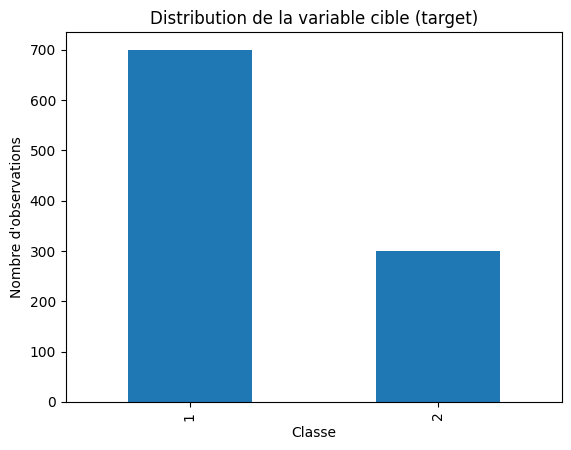

In [58]:
# Noms des colonnes selon german.doc
col_names = [
    'checking_status',   # A1  - qualitatif
    'duration',          # A2  - numérique  (mois)
    'credit_history',    # A3  - qualitatif
    'purpose',           # A4  - qualitatif
    'credit_amount',     # A5  - numérique  (DM)
    'savings_status',    # A6  - qualitatif
    'employment',        # A7  - qualitatif
    'installment_rate',  # A8  - numérique  (%)
    'personal_status',   # A9  - qualitatif
    'other_debtors',     # A10 - qualitatif
    'residence_since',   # A11 - numérique
    'property',          # A12 - qualitatif
    'age',               # A13 - numérique
    'other_plans',       # A14 - qualitatif
    'housing',           # A15 - qualitatif
    'existing_credits',  # A16 - numérique
    'job',               # A17 - qualitatif
    'liable_people',     # A18 - numérique
    'telephone',         # A19 - qualitatif
    'foreign_worker',    # A20 - qualitatif
    'target'             # A21 - cible (1=bon, 2=mauvais)
]


df = pd.read_csv('data/german.data', sep=' ', header=None, names=col_names)

#Statistique Descriptive
print("Statistique Descriptive \n")
Stats = df.describe(include="all")
print(Stats)

#Afficher les premiere ligne du Dataset
print("Affichage des 5 premiere lignes :")
print(df.head())


#Type de variables
DataType = df.dtypes
print( f'Type des data : {DataType}' )

#Afficher variables Cibles
class_counts = df['target'].value_counts()
print(f' Balance des calsses : {class_counts}')

# graphique
df["target"].value_counts().plot(kind="bar")
plt.title("Distribution de la variable cible (target)")
plt.xlabel("Classe")
plt.ylabel("Nombre d'observations")
plt.show()



## 700 Bon payeur et 300 Mauvais payeur

## 2. Préparation des Données (Data Engineering)
Nettoyage : Détection et nettoyage des valeurs manquantes.

Encodage : Conversion des variables catégorielles en données numériques. (si nécéssaire)

Feature Scaling : Mise à l'échelle des données (Standardisation ou Normalisation avec justification),

In [66]:
#Nettoyage : 'target'

Null = df.isnull().sum()
print(f' Nombres de variables NUll : {Null}')
# 0 Valeurs Manquante

#Encodage : categoriel a numerique
Le = LabelEncoder()
X = df.drop("target", axis=1)
y = df["target"]

for col in X.columns:
    if X[col].dtype == "str":
        print("Encodage de la colonne :", col)
        X[col] = Le.fit_transform(X[col])

#Appercus des colonne encoder
print(f" Variable Encoder : {X} ")


 Nombres de variables NUll : checking_status     0
duration            0
credit_history      0
purpose             0
credit_amount       0
savings_status      0
employment          0
installment_rate    0
personal_status     0
other_debtors       0
residence_since     0
property            0
age                 0
other_plans         0
housing             0
existing_credits    0
job                 0
liable_people       0
telephone           0
foreign_worker      0
target              0
dtype: int64
Encodage de la colonne : checking_status
Encodage de la colonne : credit_history
Encodage de la colonne : purpose
Encodage de la colonne : savings_status
Encodage de la colonne : employment
Encodage de la colonne : personal_status
Encodage de la colonne : other_debtors
Encodage de la colonne : property
Encodage de la colonne : other_plans
Encodage de la colonne : housing
Encodage de la colonne : job
Encodage de la colonne : telephone
Encodage de la colonne : foreign_worker
 Variable Encoder 

## Normalisation

In [71]:
#Features Scaling : 'target' Avec NORMALISATION

#Separer les Data test et train
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.2,random_state=42)

normScaler = StandardScaler()
normScaler.fit_transform(X_train)


X_train_scaled = normScaler.transform(X_train)
X_test_scaled = normScaler.transform(X_test)


# 4. Vérifier le résultat
print(f" Variable Encoder : {X_train_scaled} ")


 Variable Encoder : [[-1.27298066  3.29708155  0.42039443 ... -0.40973554  1.1751393
  -0.19044535]
 [ 0.31700299 -0.00805096  1.33678555 ... -0.40973554 -0.85096294
  -0.19044535]
 [ 1.11199481 -1.27925578 -0.49599669 ... -0.40973554 -0.85096294
  -0.19044535]
 ...
 [ 1.11199481  0.24619     1.33678555 ... -0.40973554 -0.85096294
  -0.19044535]
 [-0.47798883 -0.77077385 -0.49599669 ... -0.40973554  1.1751393
  -0.19044535]
 [ 1.11199481 -1.27925578  0.42039443 ... -0.40973554 -0.85096294
  -0.19044535]] 


## Justification :

La mise à l’échelle des données a été réalisée à l’aide de la méthode StandardScaler. Cette technique permet de standardiser les variables en centrant les données autour de zéro et en réduisant l’influence des variables ayant des valeurs élevées. Cette étape est particulièrement importante pour les modèles basés sur la distance comme k-NN , Decison tree ou Naive Bayes.



## Modelisation

K-NN -
Decison tree -
Naive Bayes

In [ ]:

# training KNN

#training arbre de decision

#training Naive bayes


